In [33]:
%pip install davos
import davos
import warnings

davos.config.suppress_stdout = True

Note: you may need to restart the kernel to use updated packages.


Import and install dependencies

Note: ignore NumbaDepreciationWarnings...

In [34]:
smuggle pandas as pd      # pip: pandas==2.0.1
smuggle hypertools as hyp # pip: hypertools==0.8.0
smuggle seaborn as sns    # pip: seaborn==0.12.2

smuggle sklearn as sk     # pip: scikit-learn==1.2.2
from sklearn.cluster import KMeans

smuggle scipy as sp       # pip: scipy==1.10.1
from scipy.spatial.distance import pdist, cdist, squareform

from mat73 smuggle loadmat # pip: mat73==0.60

smuggle requests          # pip: requests==2.28.2
smuggle nibabel as nib    # pip: nibabel==5.1.0
smuggle timecorr as tc    # pip: git+https://github.com/ContextLab/timecorr@9d567e2
smuggle nilearn as nl     # pip: nilearn==0.10.1
from nilearn.maskers import NiftiMasker
from nilearn.plotting import plot_anat, plot_glass_brain, plot_connectome

smuggle nltools as nlt    # pip: nltools==0.4.7

from matplotlib smuggle pyplot as plt  # pip: matplotlib==3.7.1
from matplotlib import animation as ani
from matplotlib.colors import ListedColormap
from tqdm smuggle tqdm    # pip: tqdm==4.64.1
smuggle numpy as np

import warnings
import os
import shutil
import zipfile
import pickle
from glob import glob as lsdir

from helpers import nii2cmu, cmu2nii, basedir, figdir, datadir, scratch_dir, raw_data_url, get_factors, get_weights

%matplotlib inline

Download fMRI data

In [35]:
raw_datadir = os.path.join(datadir, 'DFFR')
if not os.path.exists(raw_datadir):
    raw_zip = os.path.join(datadir, 'DFFR.zip')
    if not os.path.exists(raw_zip):
        print('Downloading raw data...')
        with open(raw_zip, 'wb') as f:
            data = requests.get(raw_data_url).content
            f.write(data)

    print('Extracting raw data...')
    with zipfile.ZipFile(raw_zip, 'r') as zip_ref:
        zip_ref.extractall(datadir)
    shutil.rmtree(os.path.join(datadir, '__MACOSX'))
    os.remove(raw_zip)

Exclude participants with incompatable data (following [Manning et al., 2016](https://link.springer.com/article/10.3758/s13423-016-1024-7?dom=AOL)):
  - 072413_DFFR_0: sync pulses were not captured correctly, resulting in incorrect timing during experiment
  - 112313_DFFR_0: participant exhibited ceiling performance, so there's no "forgetting" to measure

In [36]:
def reg_file2subj(fname):
    return os.path.split(fname)[1][:-len('_regs_results.mat')]

exclude = ['072413_DFFR_0', '112313_DFFR_0']

Load in regressors (descriptions of what's happening in the experiment at each moment of scanning) and behavioral data

In [37]:
regmats = {reg_file2subj(r): sp.io.loadmat(r)['all_regressors'][:-1, :] for r in lsdir(os.path.join(datadir, 'regressors', '*_regs_results.mat')) if reg_file2subj(r) not in exclude}
behavior = {os.path.split(r)[1][:-4]: loadmat(r) for r in lsdir(os.path.join(datadir, 'regressors', '*_0.mat')) + lsdir(os.path.join(datadir, 'regressors', '*_1.mat')) if os.path.split(r)[1][:-4] not in exclude}

Display an example regressors matrix

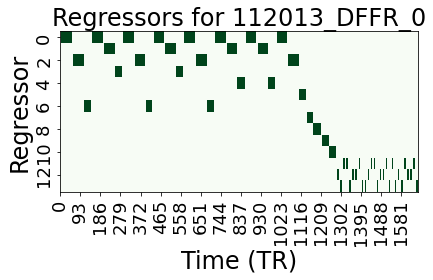

In [38]:
# display an example regressors matrix
subj = np.random.choice(list(regmats.keys()))
sns.heatmap(regmats[subj], cmap='Greens', cbar=False)
plt.title(f'Regressors for {subj}', fontsize=24)
plt.xlabel('Time (TR)', fontsize=24)
plt.ylabel('Regressor', fontsize=24);
sns.despine(top=False, right=False, left=False, bottom=False)

plt.tight_layout()

Load in description of regressors

In [39]:
reg_key = pd.read_csv(os.path.join(datadir, 'regressors', 'key.csv'))
reg_key

,block,list_id,cue,behavior,stimulus
0,1,1,NaN,present,word
1,1,2,remember,present,word
2,1,2,forget,present,word
3,1,1,remember,recall,NaN
4,1,2,remember,recall,NaN
5,1,1,forget,recall,NaN
6,1,2,forget,recall,NaN
7,2,1,NaN,present,word
8,2,1,NaN,recall,NaN
9,2,2,NaN,present,word


Display the example participant's serial position curves for remember + forget lists

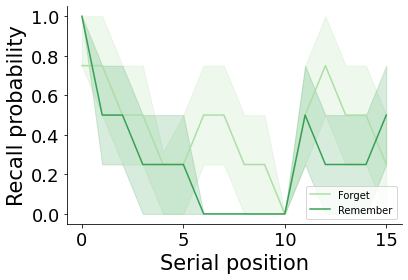

In [40]:
spc = pd.DataFrame(behavior[subj]['spc']).reset_index().rename({'index': 'List'}, axis=1).melt(id_vars='List', var_name='Serial position', value_name='Recall probability')
spc['Cue'] = spc['List'].apply(lambda x: 'Remember' if behavior[subj]['cuetype'][x] == 0 else 'Forget')

sns.lineplot(spc, x='Serial position', y='Recall probability', hue='Cue', palette='Greens', errorbar=('ci', 50));
sns.despine(top=True, right=True)
plt.legend(loc='lower right', fontsize=10);

Load in [Schaefer et al. (2018) parcellation](https://github.com/ThomasYeoLab/CBIG/tree/master/stable_projects/brain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI) for $k = 1000$ parcels

In [71]:
key = os.path.join(datadir, 'networks', os.path.join(datadir, 'networks', 'Schaefer2018_1000Parcels_17Networks_order.txt'))
key = pd.read_csv(key, sep='\t', header=None, names=['id', 'name', 'x', 'y', 'z', 't']).drop('t', axis=1)
key['study'] = key['name'].apply(lambda x: x.split('_')[0])
key['hemisphere'] = key['name'].apply(lambda x: x.split('_')[1][0])
key['network'] = key['name'].apply(lambda x: x.split('_')[2])
key.drop('name', axis=1, inplace=True)

lookup_table = {
    'VisCent': 'Visual central',
    'VisPeri': 'Visual peripheral',
    'SomMotA': 'Somatomotor A',
    'SomMotB': 'Somatomotor B',
    'DorsAttnA': 'Dorsal attention A',
    'DorsAttnB': 'Dorsal attention B',
    'SalVentAttnA': 'Salience/ventral attention A',
    'SalVentAttnB': 'Salience/ventral attention B',
    'LimbicA': 'Limbic A',
    'LimbicB': 'Limbic B',
    'ContA': 'Control A',
    'ContB': 'Control B',
    'ContC': 'Control C',
    'DefaultA': 'Default mode A',
    'DefaultB': 'Default mode B',
    'DefaultC': 'Default mode C',
    'TempPar': 'Temporal parietal',
}

network_colors = {
    'Visual central': '#BE1E2D',
    'Visual peripheral': '#C85248',
    'Somatomotor A': '#F15A29',
    'Somatomotor B': '#F47C4B',
    'Dorsal attention A': '#F7941D',
    'Dorsal attention B': '#FAA74A',
    'Salience/ventral attention A': '#F9ED32',
    'Salience/ventral attention B': '#FBF392',
    'Limbic A': '#009444',
    'Limbic B': '#7CB380',
    'Control A': '#1C75BC',
    'Control B': '#7D9FD3',
    'Control C': '#556683',
    'Default mode A': '#92278F',
    'Default mode B': '#B37AB4',
    'Default mode C': '#844984',
    'Temporal parietal': '#DA1C5C',
}

colors = ['#888888']
colors.extend([v for k, v in network_colors.items()])
network_cmap = ListedColormap(colors, N=len(colors)*2, name='networks')  # why do I need to double the number of colors?

network_codes = {k: i + 1 for i, k in enumerate(lookup_table.values())}

key['network'] = key['network'].apply(lambda x: lookup_table[x])
key['code'] = key['network'].apply(lambda x: network_codes[x])
key.set_index('id', inplace=True)
key.loc[0, 'code'] = 0  # append a background (non-network) code
key

,x,y,z,study,hemisphere,network,code
id,,,,,,,
1,120.0,18.0,135.0,17Networks,L,Visual central,1.0
2,120.0,18.0,136.0,17Networks,L,Visual central,1.0
3,120.0,18.0,137.0,17Networks,L,Visual central,1.0
4,120.0,18.0,138.0,17Networks,L,Visual central,1.0
5,120.0,17.0,130.0,17Networks,L,Visual central,1.0
...,...,...,...,...,...,...,...
997,9.0,42.0,250.0,17Networks,R,Temporal parietal,17.0
998,9.0,42.0,251.0,17Networks,R,Temporal parietal,17.0
999,9.0,42.0,252.0,17Networks,R,Temporal parietal,17.0


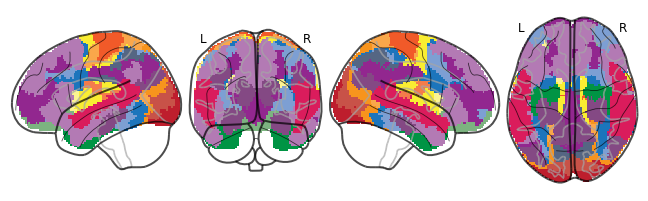

In [72]:
parcels_fname = os.path.join(datadir, 'networks', 'Schaefer2018_1000Parcels_17Networks_order_FSLMNI152_2mm.nii.gz')

# use to construct ROI averages
mask = nlt.expand_mask(nlt.Brain_Data(parcels_fname))

# use this for plotting
nx = nlt.Brain_Data(parcels_fname)
nx.data = np.array([key.loc[i, 'code'] for i in nx.data]).astype(float)
networks = nx.to_nifti()

fname = os.path.join(figdir, 'networks.pdf')
nl.plotting.plot_glass_brain(networks, cmap=network_cmap, display_mode='lyrz', output_file=fname)

# also display figure here
nl.plotting.plot_glass_brain(networks, cmap=network_cmap, display_mode='lyrz');

Infer parcel centers and widths

In [73]:
def get_centers_and_widths(parcels_fname):
    parcels = nii2cmu(parcels_fname)
    Y, R = parcels['Y'], parcels['R']
    Y = Y.astype(int)
    centers = np.zeros((Y.max() - Y.min() + 1, 3))
    widths = np.zeros(Y.max() - Y.min() + 1)

    for i in np.unique(Y):
        mask = (Y == i).ravel()
        centers[i - 1] = np.mean(R[mask, :], axis=0)
        widths[i - 1] = np.mean(cdist(R[mask, :], centers[i - 1].reshape(1, -1)))
    
    return centers, widths

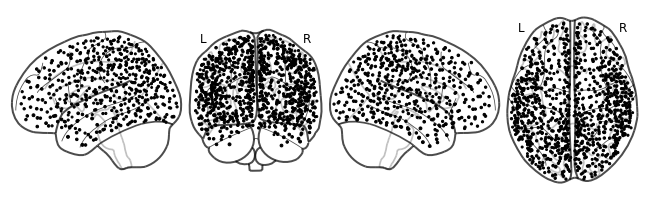

In [74]:
centers, widths = get_centers_and_widths(parcels_fname)
plot_connectome(np.eye(centers.shape[0]), centers, node_size=widths, node_color='k', display_mode='lyrz');

Load .nii.gz images for each participant

In [76]:
def nii_fname2subj(fname):
    return os.path.split(fname)[1][:-len('.nii.gz')]

nii_files = [x for x in lsdir(os.path.join(datadir, 'DFFR', '*.nii.gz')) if nii_fname2subj(x) not in exclude]
print(f'Found data for {len(nii_files)} participants.')

Found data for 23 participants.


Apply mask to .nii.gz images

In [77]:
def apply_mask(fname, mask, img=None):
    if img is None:
        img = nlt.Brain_Data(fname)
    
    x = np.zeros((len(img), len(mask)))
    for i, m in enumerate(mask):
        x[:, i] = img.extract_roi(m)
    
    return x

Compute the correlations between upper triangles of the timepoints-by-timepoints correlation matrices for the original and reduced representations of the data, for each participant.

In [78]:
corrs = []
data = {}
for n in tqdm(nii_files):
    fname = os.path.join(scratch_dir, f'{nii_fname2subj(n)}_{len(mask)}_parcels.pkl')

    if os.path.exists(fname):
        with open(fname, 'rb') as f:
            x, original_corrmat, reduced_corrmat = pickle.load(f)
    else:
        img = nlt.Brain_Data(n)
        x = apply_mask(n, mask, img=img)
        
        # compute correlation matrices
        original_corrmat = 1 - pdist(img.data, metric='correlation')
        reduced_corrmat = 1 - pdist(x, metric='correlation')

        with open(fname, 'wb') as f:
            pickle.dump([x, original_corrmat, reduced_corrmat], f)

    corrs.append(np.corrcoef(original_corrmat, reduced_corrmat)[0, 1])
    data[nii_fname2subj(n)] = x

100%|██████████| 23/23 [00:00<00:00, 92.31it/s]


<Axes: >

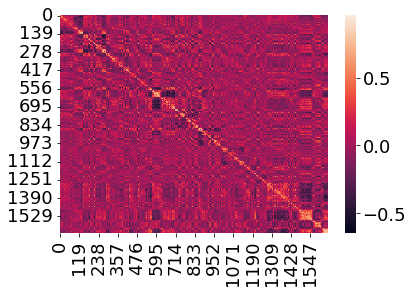

In [79]:
sns.heatmap(squareform(original_corrmat))

<Axes: >

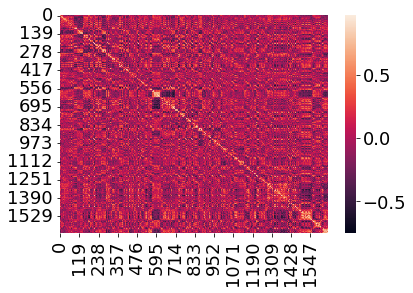

In [80]:
sns.heatmap(squareform(reduced_corrmat))

Plot histogram of correlation coefficients between original vs. reduced correlation matrices

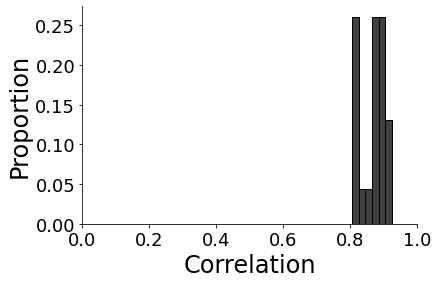

In [81]:
sns.histplot(corrs, color='k', stat='proportion')
plt.xlabel('Correlation', fontsize=24)
plt.ylabel('Proportion', fontsize=24)
plt.xlim([0, 1])
sns.despine(top=True, right=True);

For each participant and cue type (remember/forget), compute the average (masked) brain activity from $-n$ to $n$ seconds relative to the memory cue

In [82]:
def get_bounds(x): #x is a line from a regressors matrix
    diffs = np.diff(np.array(x, dtype=np.float16)) #strange things happen when x is an array of ints
    return np.where(diffs == 1)[0], np.where(diffs == -1)[0] #event starts, ends

In [83]:
def cue_times(regmats):
    if type(regmats) is dict:
        return {k: cue_times(v) for k, v in regmats.items()}
    
    # see reg_key
    _, end_L1 = get_bounds(regmats[0, :])       # List 1 presentation times
    start_L2_R, _ = get_bounds(regmats[1, :])   # List 2 presentation times following remember cues
    start_L2_F, _ = get_bounds(regmats[2, :])   # List 2 presentation times following forget cues

    end_L1_R = end_L1[np.where(cdist(np.atleast_2d(end_L1).T, np.atleast_2d(start_L2_R).T) < 10)[0]]
    end_L1_F = end_L1[np.where(cdist(np.atleast_2d(end_L1).T, np.atleast_2d(start_L2_F).T) < 10)[0]]

    return {'remember': np.round((end_L1_R + start_L2_R) / 2), 'forget': np.round((end_L1_F + start_L2_F) / 2)}

memory_cues = cue_times(regmats)

In [84]:
def event_triggered_average(data, event_times, before=25, after=25):
    '''
    return the data, centered on each event_time. the resulting matrix is of shape
    (before + after + 1) by data.shape[1] by len(event_times).  if an event starts
    or ends too close to the beginning or end of the given data, the slice of that
    event's representation in the result will contain nans to reflect the missing
    data.
    '''
    if type(data) is dict:
        return {k: event_triggered_average(v, event_times[k], before=before, after=after) for k, v in data.items()}

    if type(event_times) is dict:
        return {k: event_triggered_average(data, v, before=before, after=after) for k, v in event_times.items()}
    
    x = np.multiply(np.nan, np.zeros([before + after + 1, data.shape[1], len(event_times)]))
    for i, t in enumerate(event_times):
        start_time = t - before - 1
        end_time = t + after
        
        if start_time >= 0:
            start_ind = 0
        else:
            start_ind = np.abs(start_time)
            start_time = 0
        
        if end_time <= data.shape[0]:
            end_ind = before + after + 1
        else:
            end_ind = end_time - data.shape[0]
            end_time = data.shape[0]
        
        start_ind, end_ind, start_time, end_time = int(start_ind), int(end_ind), int(start_time), int(end_time)
        x[start_ind:end_ind, :, i] = data[start_time:end_time, :]
    return np.mean(x, axis=2)

Compute remember and forget event-triggered-averages (ETAs) for each participant

In [85]:
etas = event_triggered_average(data, memory_cues, before=50, after=50)

subjects = list(etas.keys())
remember_etas = [etas[s]['remember'] for s in subjects]
forget_etas = [etas[s]['forget'] for s in subjects]

Set timecorr kernel to the left half of a Gaussian

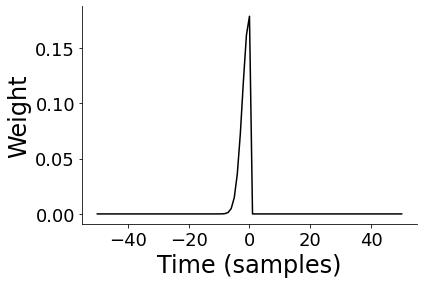

In [86]:
def gaussian_back(T, params=tc.helpers.gaussian_params):
    return np.tril(tc.helpers.gaussian_weights(T, params=params))

T = remember_etas[0].shape[0]
var = 5
kernel = gaussian_back(T, params={'var': var})
plt.plot(np.linspace(-(T - 1)/2, (T - 1) / 2, T), kernel[int((T - 1) / 2), :], 'k')
plt.xlabel('Time (samples)', fontsize=24)
plt.ylabel('Weight', fontsize=24)
sns.despine(top=True, right=True);

Compute remember and forget networks

In [87]:
fname = os.path.join(scratch_dir, f'isfc_{len(mask)}_parcels_T{T}_var{var}.pkl')

if os.path.exists(fname):
    with open(fname, 'rb') as f:
        remember_isfc, forget_isfc = pickle.load(f)
else:
    remember_isfc = tc.timecorr(remember_etas, weights_function=gaussian_back, weights_params={'var': var}, combine=tc.helpers.corrmean_combine)
    forget_isfc = tc.timecorr(forget_etas, weights_function=gaussian_back, weights_params={'var': var}, combine=tc.helpers.corrmean_combine)

    with open(fname, 'wb') as f:
        pickle.dump([remember_isfc, forget_isfc], f)

remember_isfc = tc.vec2mat(remember_isfc)
forget_isfc = tc.vec2mat(forget_isfc)

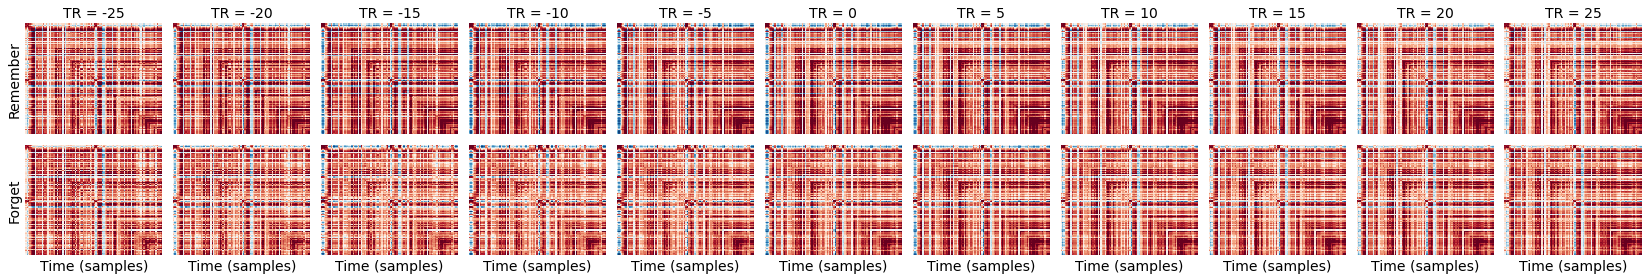

In [65]:
n = 11
fig, ax = plt.subplots(2, n, figsize=(2 * n + 1, 4), sharex=True, sharey=True)

for i, t in enumerate(np.round(np.linspace(-(T - 1) / 4, (T - 1) / 4, n))):
    sns.heatmap(remember_isfc[:, :, i], ax=ax[0, i], vmin=-0.5, vmax=0.5, cmap='RdBu_r', cbar=False)
    sns.heatmap(forget_isfc[:, :, i], ax=ax[1, i], vmin=-0.5, vmax=0.5, cmap='RdBu_r', cbar=False)
    ax[0, i].set_title(f'TR = {int(t)}', fontsize=14)
    
    if i == 0:
        ax[0, i].set_ylabel('Remember', fontsize=14)
        ax[1, i].set_ylabel('Forget', fontsize=14)
    ax[1, i].set_xlabel('Time (samples)', fontsize=14)

    ax[0, i].set_xticks([])
    ax[0, i].set_yticks([])

plt.tight_layout()

fig.savefig(os.path.join(figdir, 'isfc.pdf'), bbox_inches='tight')

In [56]:
def ribbon(x, y, lb, ub=None, color='k', alpha=0.5):
    #assert is_sorted(x), 'x-coordinates must be monotonically increasing'
    
    if ub is None:
        ub = lb
    h1 = plt.fill_between(x, y-lb, y+ub, color=color, alpha=alpha)
    h2 = plt.plot(x, y, color=color)
    return h1, h2

In [57]:
def event_ribbon(x, ts=None, limit_t=None, color='k', alpha=0.5):
    if ts is None:
        ts = np.arange(-(x.shape[0] - 1)/2, (x.shape[0] - 1)/2 + 1) #assume centered data
    
    if not (limit_t is None):
        inds = (ts >= np.min(limit_t)) & (ts <= np.max(limit_t))
    else:
        inds = np.ones(ts.shape[0]) > 0
    
    x = x[inds, :]
    ts = ts[inds]
                
    m = np.nanmean(x, axis=1)
    ci = 1.96*np.divide(np.nanstd(x, axis=1), np.sqrt(x.shape[1])) # 95% confidence intervals
    
    return ribbon(ts, m, ci, ci, color=color, alpha=alpha)

In [58]:
buffer = 50
r_f_nets = get_network_dynamics(data, [1, 2], weights_function=kernel_weights, weights_params=kernel_params, before=buffer, after=buffer, offset=0, include_timepoints='pre', exclude_timepoints=10)


NameError: name 'get_network_dynamics' is not defined

In [ ]:
means = list(map(tc.corrmean_combine, r_f_nets))
diffs = list(map(lambda x, y: x - y, r_f_nets[0], r_f_nets[1]))
tvals, pvals = tc.tstat_combine(diffs, return_pvals=True)
filtered_tvals = np.multiply(tvals, (pvals < 0.0001/np.sum(np.isnan(pvals)))) #Bonferroni corrected p < 0.0001

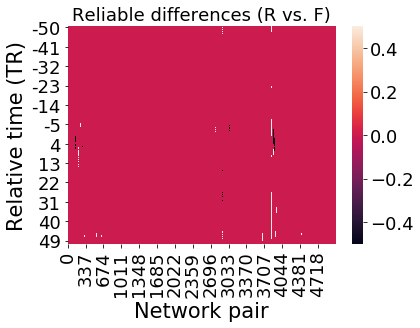

In [ ]:
sns.heatmap(pd.DataFrame(np.multiply(tvals, (pvals < 0.05/np.sum(np.isnan(pvals)))), index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Reliable differences (R vs. F)');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

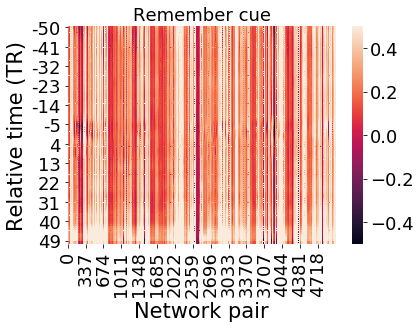

In [ ]:
sns.heatmap(pd.DataFrame(means[0], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Remember cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

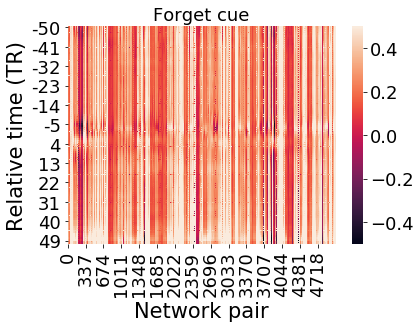

In [ ]:
sns.heatmap(pd.DataFrame(means[1], index=np.arange(-buffer, buffer+1)), vmin=-0.5, vmax=0.5)
plt.title('Forget cue');
plt.ylabel('Relative time (TR)');
plt.xlabel('Network pair');

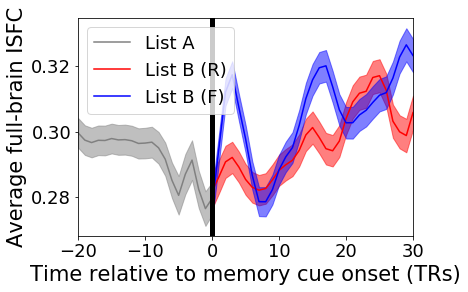

In [ ]:
ts = np.arange(-buffer, buffer+1)
min_time = -20
max_time = 30

colors = [[0.5, 0.5, 0.5], 'r', 'b']
event_ribbon(np.mean(np.concatenate([means[0][:, :, np.newaxis], means[1][:, :, np.newaxis]], axis=2), axis=2), ts=ts, color=colors[0], limit_t=[min_time, 0]);
event_ribbon(means[0], ts=ts, color=colors[1], limit_t=[0, max_time]);
event_ribbon(means[1], ts=ts, color=colors[2], limit_t=[0, max_time]);
plt.legend(['List A', 'List B (R)', 'List B (F)'])


plt.xlabel('Time relative to memory cue onset (TRs)')
plt.ylabel('Average full-brain ISFC')
plt.xlim([min_time, max_time]);
y = plt.ylim();
plt.plot([0, 0], y, 'k-', linewidth=5)
plt.ylim(y);
plt.savefig(os.path.join(figdir, 'ribbon_plot.pdf'))

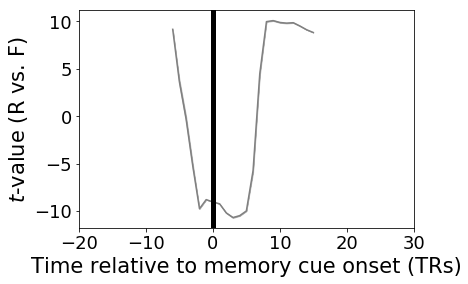

In [ ]:
nanned_filtered_tvals = filtered_tvals
nanned_filtered_tvals[nanned_filtered_tvals == 0] = np.nan
event_ribbon(filtered_tvals, ts=ts, color=[0.5, 0.5, 0.5], limit_t=[min_time, max_time])
plt.xlabel('Time relative to memory cue onset (TRs)')
plt.ylabel('$t$-value (R vs. F)')
plt.xlim([min_time, max_time]);
y = plt.ylim();
plt.plot([0, 0], y, 'k-', linewidth=5)
plt.ylim(y);
plt.savefig(os.path.join(figdir, 't_vals_timeseries.pdf'))

In [ ]:
eng = mlab.start_matlab()

In [ ]:
def mlab_array(x):    
    return matlab.double(x.tolist())

In [ ]:
def BrainNet_animation(centers, widths, connections, outfile, ts=None, limit_t=None, force_refresh=False):
    if ts is None:
        ts = np.arange(connections.shape[2])
    
    if not (limit_t is None):
        inds = (ts >= np.min(limit_t)) & (ts <= np.max(limit_t))
    else:
        inds = np.ones(ts.shape[0]) > 0
    
    ts = ts[inds]
    connections = connections[:, :, inds]
    
    for i, t in enumerate(ts):
        next_fname = outfile + '_' + '{:03d}'.format(i) + '.jpg'
        if (not os.path.exists(next_fname)) or force_refresh:
            eng.TFA_BrainNet_wrapper(mlab_array(centers), mlab_array(widths), mlab_array(np.squeeze(connections[:, :, i])), next_fname, os.path.join('data', 'brainnet_config_DF.mat'), nargout=0)
                                            

In [ ]:
BrainNet_animation(centers, widths, tc.vec2mat(filtered_tvals), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'diffs'), force_refresh=True)
BrainNet_animation(centers, widths, tc.vec2mat(means[0]), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'remember'), force_refresh=True)
BrainNet_animation(centers, widths, tc.vec2mat(means[1]), ts=ts, limit_t=[min_time, max_time], outfile=os.path.join(figdir, 'forget'), force_refresh=True)

In [ ]:
eng.exit()

In [ ]:
!ffmpeg -i {figdir}/diffs_%03d.jpg -c:v libx264 -r 25 {figdir}/diffs.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/diffs_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/u

In [ ]:
!ffmpeg -i {figdir}/remember_%03d.jpg -c:v libx264 -r 25 {figdir}/remember.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/remember_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470b

In [ ]:
!ffmpeg -i {figdir}/forget_%03d.jpg -c:v libx264 -r 25 {figdir}/forget.mp4

ffmpeg version 4.0.2 Copyright (c) 2000-2018 the FFmpeg developers
  built with Apple LLVM version 9.1.0 (clang-902.0.39.2)
  configuration: --prefix=/usr/local/Cellar/ffmpeg/4.0.2 --enable-shared --enable-pthreads --enable-version3 --enable-hardcoded-tables --enable-avresample --cc=clang --host-cflags= --host-ldflags= --enable-gpl --enable-libmp3lame --enable-libx264 --enable-libxvid --enable-opencl --enable-videotoolbox --disable-lzma
  libavutil      56. 14.100 / 56. 14.100
  libavcodec     58. 18.100 / 58. 18.100
  libavformat    58. 12.100 / 58. 12.100
  libavdevice    58.  3.100 / 58.  3.100
  libavfilter     7. 16.100 /  7. 16.100
  libavresample   4.  0.  0 /  4.  0.  0
  libswscale      5.  1.100 /  5.  1.100
  libswresample   3.  1.100 /  3.  1.100
  libpostproc    55.  1.100 / 55.  1.100
Input #0, image2, from 'figs/gaussian/var10/Schaefer/100_parcels/forget_%03d.jpg':
  Duration: 00:00:02.04, start: 0.000000, bitrate: N/A
    Stream #0:0: Video: mjpeg, yuvj420p(pc, bt470bg/